In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("../data/upi_transactions.csv")
df.sample(5)

,transaction_id,user_id,merchant_id,merchant_category,timestamp,amount,transaction_type,upi_app,device_id,device_is_new_for_user,device_distinct_users_seen_so_far,location,location_mismatch,account_created_date,is_fraud,fraud_scenario
86606,TXN00086607,U004163,U004049,P2P Transfer,2025-06-06 21:43:21,409.07,P2P,Google Pay,DEV-0001599,False,0,Bhopal,False,2022-08-21,0,NaN
23753,TXN00023754,U007906,M001480,Utilities,2025-02-12 22:13:01,264.96,Recharge,Google Pay,DEV-0014342,False,0,Patna,False,2024-12-28,0,NaN
16285,TXN00016286,U009398,M001223,Gaming,2025-01-30 19:52:27,207.87,P2M,BHIM,DEV-0001025,False,0,Lucknow,False,2024-12-12,0,NaN
68581,TXN00068582,U008691,M000530,E-commerce,2025-05-05 09:02:34,740.85,P2M,PhonePe,DEV-0015343,False,0,Pune,False,2023-11-17,0,NaN
74843,TXN00074844,U004691,U004755,P2P Transfer,2025-05-16 18:19:29,457.89,P2P,Google Pay,DEV-0007840,False,0,Chennai,False,2022-06-26,0,NaN


In [9]:
df.shape

(100000, 16)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   transaction_id                     100000 non-null  str    
 1   user_id                            100000 non-null  str    
 2   merchant_id                        100000 non-null  str    
 3   merchant_category                  100000 non-null  str    
 4   timestamp                          100000 non-null  str    
 5   amount                             100000 non-null  float64
 6   transaction_type                   100000 non-null  str    
 7   upi_app                            100000 non-null  str    
 8   device_id                          100000 non-null  str    
 9   device_is_new_for_user             100000 non-null  bool   
 10  device_distinct_users_seen_so_far  100000 non-null  int64  
 11  location                           100000 non-null 

In [12]:
df.describe()

,amount,device_distinct_users_seen_so_far,is_fraud
count,100000.000000,100000.000000,100000.000000
mean,668.890533,1.265340,0.034560
std,1029.229001,5.516386,0.182663
min,5.990000,0.000000,0.000000
25%,243.517500,0.000000,0.000000
50%,432.970000,0.000000,0.000000
75%,761.230000,0.000000,0.000000
max,80824.110000,46.000000,1.000000


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(df.isna().sum())

transaction_id                           0
user_id                                  0
merchant_id                              0
merchant_category                        0
timestamp                                0
amount                                   0
transaction_type                         0
upi_app                                  0
device_id                                0
device_is_new_for_user                   0
device_distinct_users_seen_so_far        0
location                                 0
location_mismatch                        0
account_created_date                     0
is_fraud                                 0
fraud_scenario                       96544
dtype: int64


- 96544 data points belong to the non-fraud category, so that's why the `fraud_scenario` feature contains missing values where is_fraud is 0. Replaced those missing values with `No Fraud Detected`, indicating there is no fraud scenario. 

In [15]:
df['fraud_scenario'] = df['fraud_scenario'].fillna('No Fraud Detected')

In [16]:
print("Start date:", min(df.timestamp))
print("End date:  ", max(df.timestamp))

Start date: 2025-01-01 00:16:59
End date:   2025-06-30 23:56:21


- The dataset contains six months' (Jan-June) transactions from 2025. 

In [17]:
# Convert the timestamp into a datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [18]:
df['time_in_seconds'] = (df['timestamp'].dt.hour * 3600 + df['timestamp'].dt.minute * 60 + df['timestamp'].dt.second)

In [19]:
fraud_df = df[df['is_fraud'] == 1]
non_fraud_df = df[df['is_fraud'] == 0]

In [20]:
def plot_fraud_rate_by_category(data, categorical_feature, target='is_fraud'):
    """Plot the Fraud rate by any categorical feature that is present in the dataset"""
    if categorical_feature not in data.columns:
        raise ValueError(f"Column {categorical_feature} is not found.")

    if target not in data.columns:
        raise ValueError(f"Target {target} is not found.")


    fraud_rate = data.groupby(categorical_feature)[target].agg(fraud_rate="mean").reset_index()
    fraud_rate['fraud_rate'] *= 100
    fraud_rate = fraud_rate.sort_values(by='fraud_rate')

    plt.figure(figsize=(12,5))

    ax = plt.barh(fraud_rate[categorical_feature], fraud_rate['fraud_rate'], color='#eb726e')

    axes = plt.gca() # get the current axes

    for patch in ax.patches:
        width = patch.get_width()

        axes.text(width+0.01, patch.get_y() + patch.get_height() / 2, f'{width:.1f}%', va='center', ha='left')

    plt.xlabel("Fraud Rate (%)")
    plt.ylabel(f"{categorical_feature.replace('_', ' ').title()}")
    plt.title(f"Fraud Rate by {categorical_feature.replace('_', ' ').title()}")

    plt.grid('x', alpha=0.5)
    plt.tight_layout()
    plt.show()

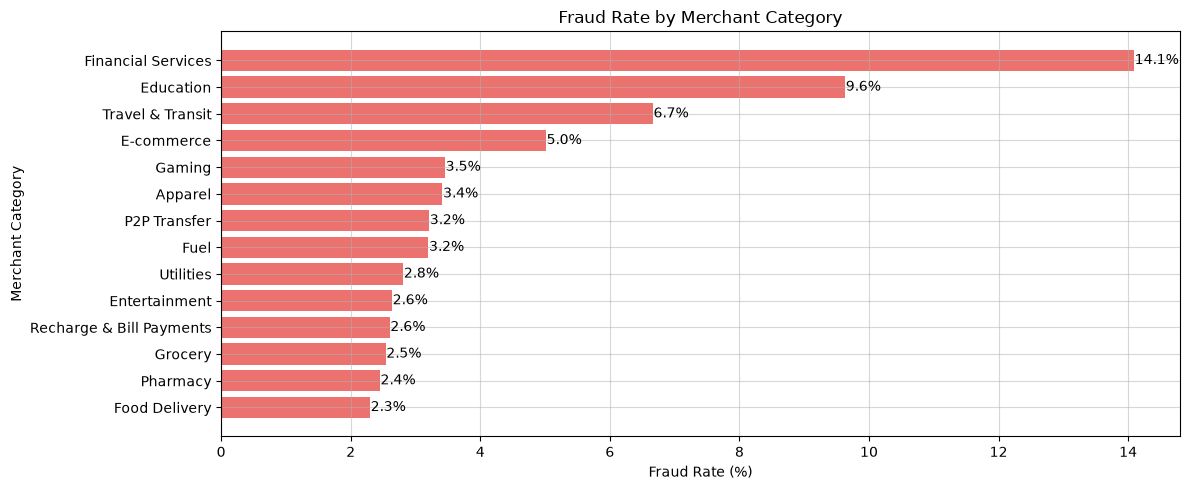

In [21]:
plot_fraud_rate_by_category(df, 'merchant_category')

- The financial services merchant category has the highest fraud rate at 14.1%, followed by the education and travel and transit merchant category.

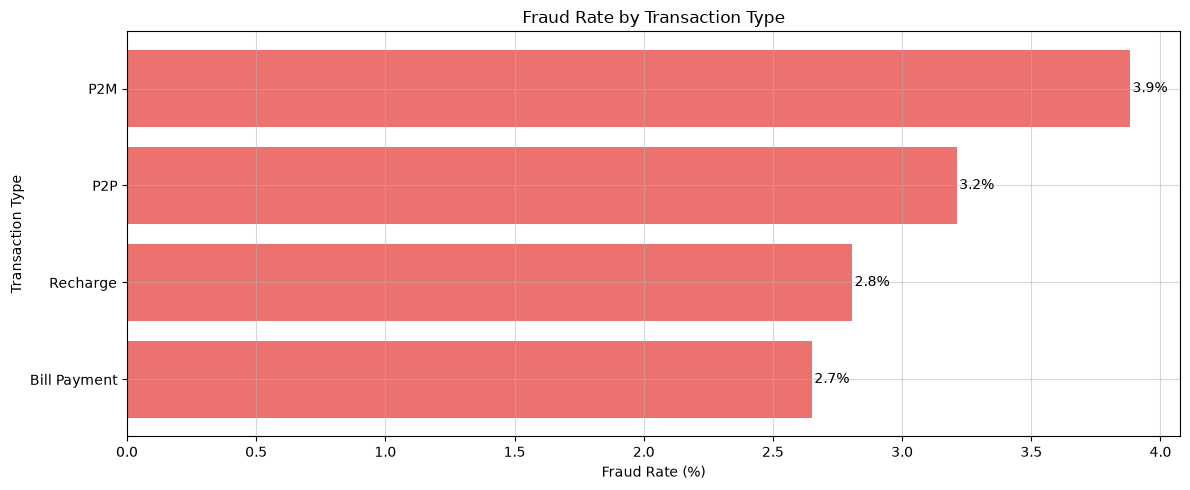

In [22]:
plot_fraud_rate_by_category(df, 'transaction_type')

- P2M (Peer-to-Merchant) transactions have the highest fraud rate at 3.9%, followed by P2P (Peer-to-Peer) and recharge transactions.

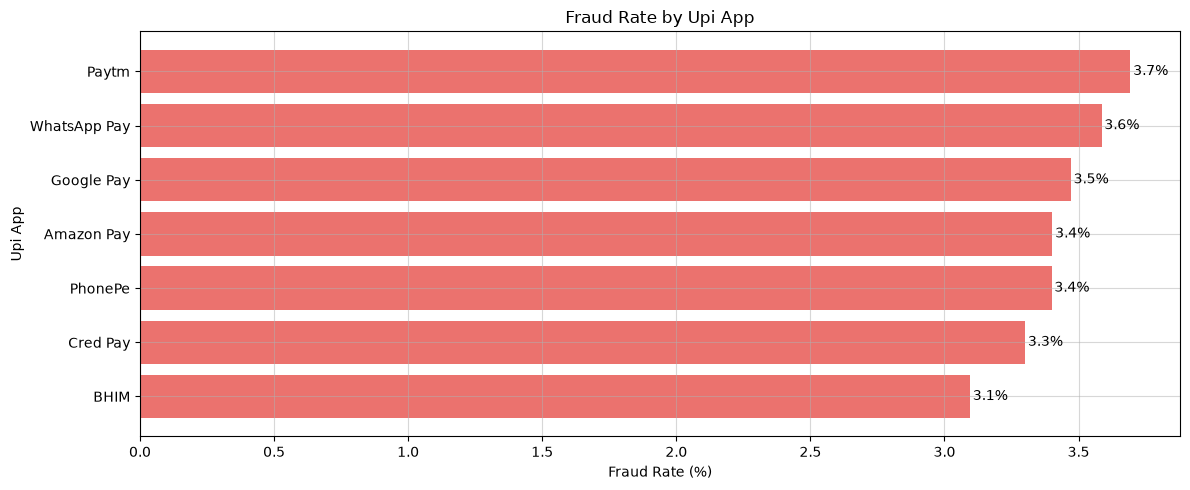

In [23]:
plot_fraud_rate_by_category(df, 'upi_app')

- Paytm has the highest fraud rate, followed by WhatsApp Pay and Google Pay.

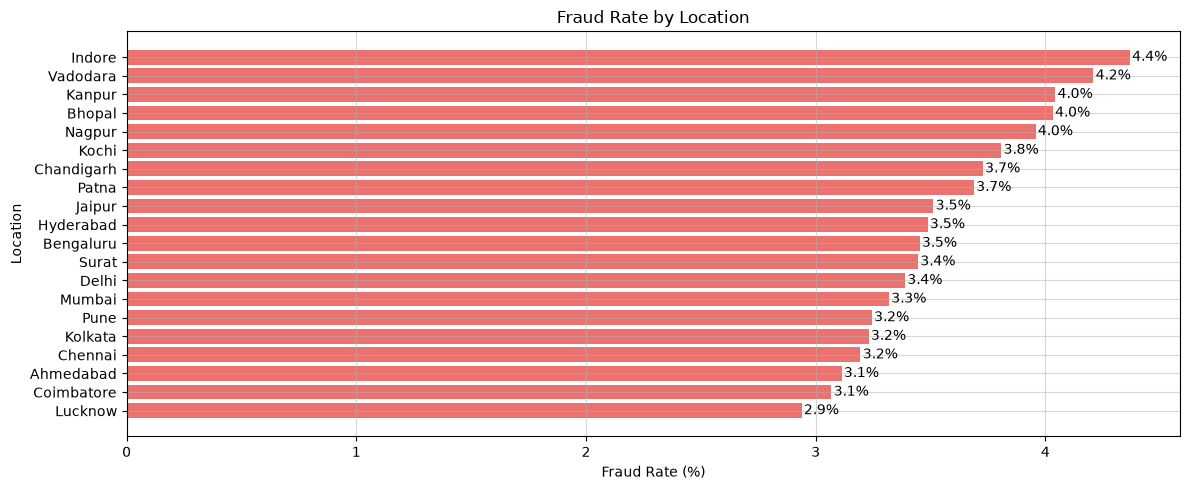

In [24]:
plot_fraud_rate_by_category(df, 'location')

- Fraud rates are higher in the following locations: Indore, Vadodara, Kanpur, Bhopal, and Nagpur.

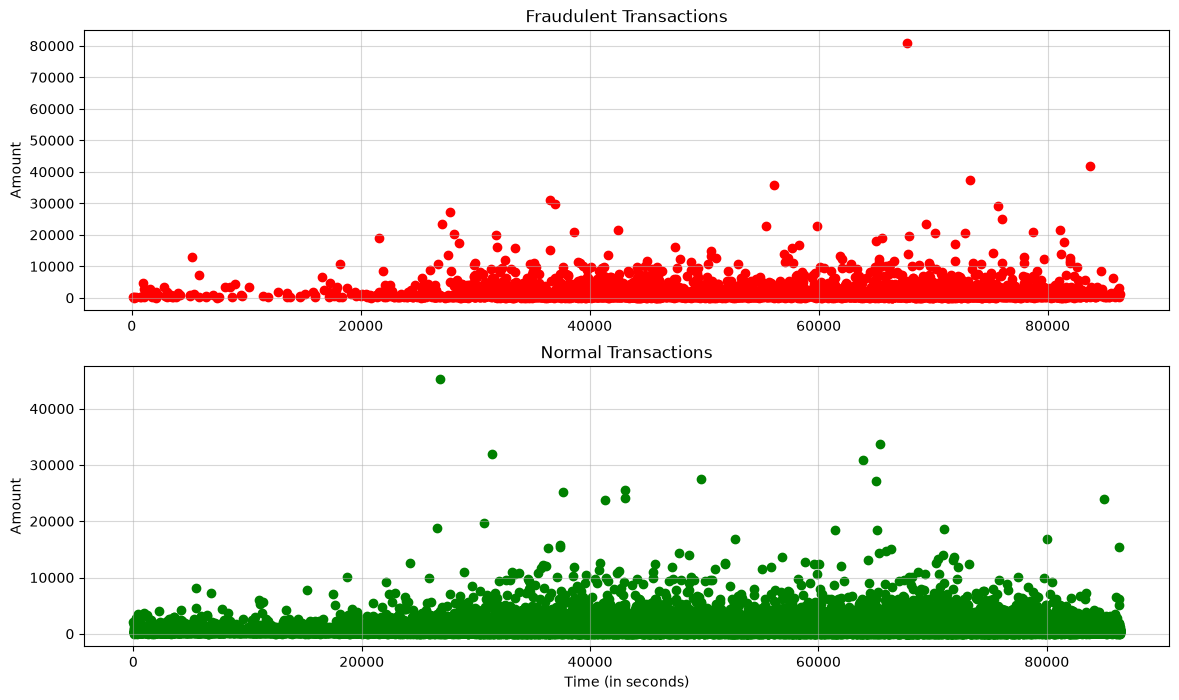

In [25]:
# time vs amount plot between fraudulent and normal transactions 
plt.figure(figsize=(14,8))

plt.subplot(2,1,1)
plt.scatter(fraud_df['time_in_seconds'], fraud_df['amount'], color='red')
plt.title("Fraudulent Transactions")
plt.ylabel("Amount")
plt.grid('x', alpha=0.5)

plt.subplot(2,1,2)
plt.scatter(non_fraud_df['time_in_seconds'], non_fraud_df['amount'], color='green')
plt.title("Normal Transactions")
plt.xlabel("Time (in seconds)")
plt.ylabel("Amount")
plt.grid('x', alpha=0.5)

plt.show()

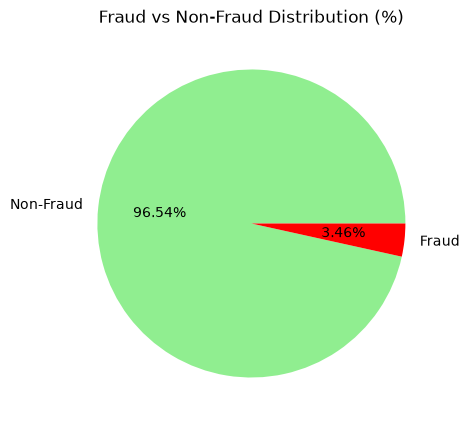

In [26]:
distri_df = df['is_fraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))
plt.pie(distri_df, labels=['Non-Fraud', 'Fraud'], colors=['lightgreen','red'], autopct='%.2f%%')
plt.title("Fraud vs Non-Fraud Distribution (%)")
plt.show()

- The dataset is highly imbalanced, with fraudulent transactions accounting for only 3.46% of the total.

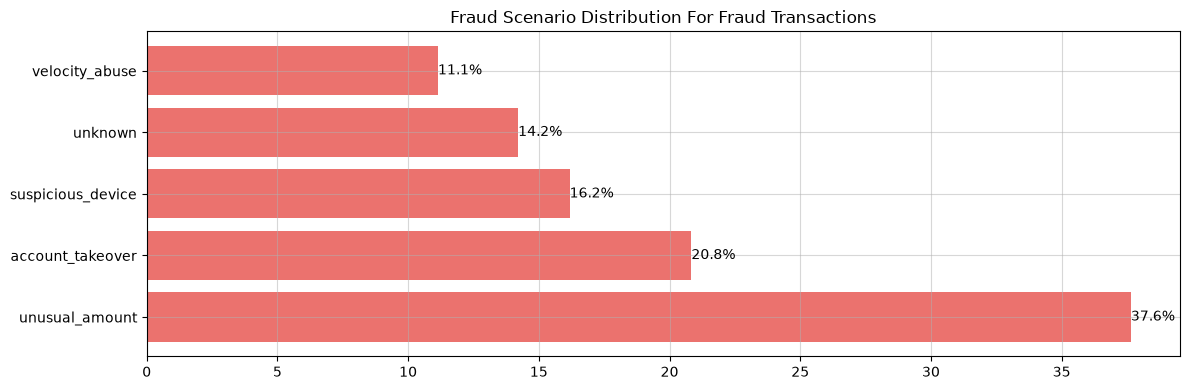

In [27]:
# plotting the category distribution of fraud scenario
fraud_sce_dist = fraud_df.fraud_scenario.value_counts(normalize=True) * 100

plt.figure(figsize=(12,4))
ax = plt.barh(fraud_sce_dist.index, fraud_sce_dist.values, color='#eb726e')

axes = plt.gca() # get the current axes

for patch in ax.patches:
    width = patch.get_width()
    axes.text(width+0.001, patch.get_y() + patch.get_height() / 2, f'{width:.1f}%', va='center', ha='left')
    
    
plt.title("Fraud Scenario Distribution For Fraud Transactions")
plt.grid('x', alpha=0.5)
plt.tight_layout()
plt.show()

- 37.6% of fraudulent transactions are associated with unusual-amount fraud, followed by account takeover and suspicious-device scenarios.

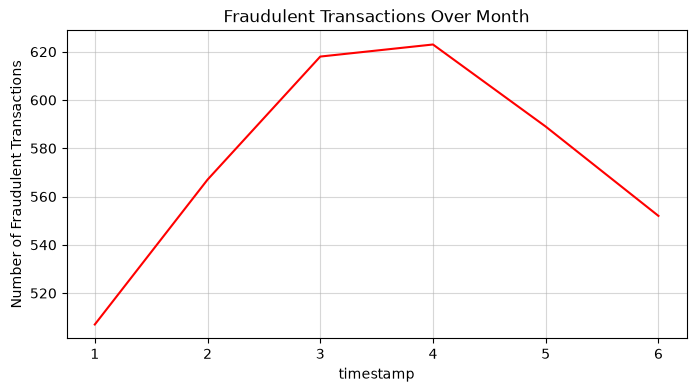

In [28]:
# plotting number of fraudulent transactions over the month in 2025
plt.figure(figsize=(8,4))
fraud_df.groupby(fraud_df['timestamp'].dt.month).size().plot(color='red')
plt.title("Fraudulent Transactions Over Month")
plt.ylabel("Number of Fraudulent Transactions")
plt.grid('x', alpha=0.5)
plt.show()

- The number of fraudulent transactions peaked in March and April.

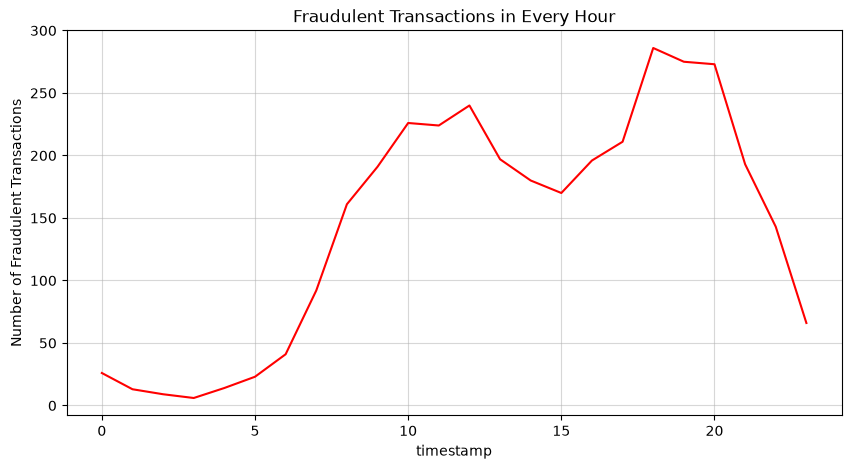

In [29]:
# plotting number of fraudulent transactions every hour 

plt.figure(figsize=(10, 5))
fraud_df.groupby(fraud_df['timestamp'].dt.hour).size().plot(color='red')
plt.title("Fraudulent Transactions in Every Hour")
plt.ylabel("Number of Fraudulent Transactions")
plt.grid('x', alpha=0.5)
plt.show()

- Most fraudulent transactions occurred between 10 a.m. and 10 p.m., from the afternoon into the evening.

In [30]:
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

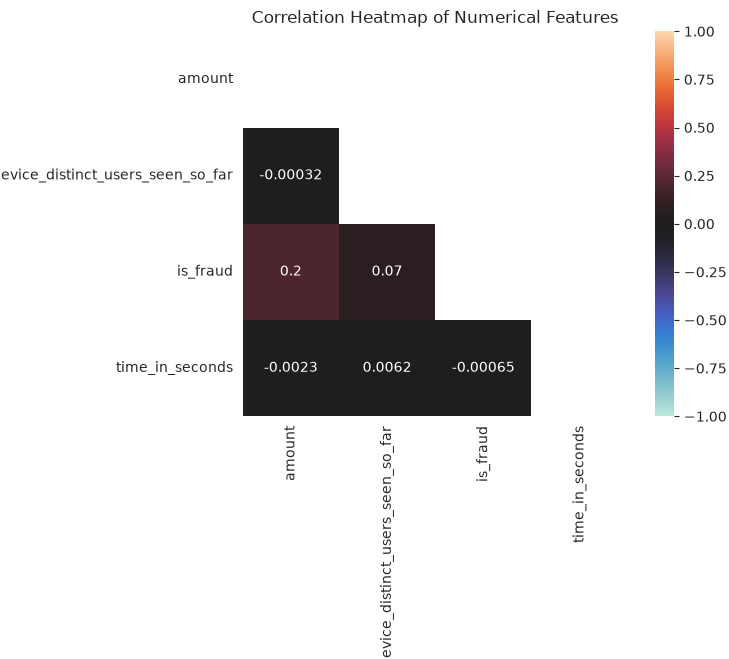

In [42]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(7,5))
with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, vmin=-1, center=0, vmax=1, square=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

- Higher values of the device_distinct_users_seen_so_far feature and larger transaction amounts are associated with fraudulent cases.